# Test du solveur de l'équation de la chaleur

Ce notebook teste les implémentations explicite (Numba) et implicite (Scipy) du solveur de l'équation de la chaleur.


In [16]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

# Ajouter le répertoire core au path pour pouvoir importer le solveur
sys.path.append(os.path.abspath('../src'))

from heat_solver import solve_heat_explicit, solve_heat_implicit


## Configuration des paramètres


In [17]:
L = 1.0        # Longueur du domaine
nx = 100       # Nombre de points d'espace
dx = L / (nx - 1)
x = np.linspace(0, L, nx)

alpha = 0.01   # Diffusivité
dt = 0.001     # Pas de temps
nt = 500       # Nombre de pas de temps

r = alpha * dt / dx**2
print(f"Stabilité (r = alpha * dt / dx^2): {r:.4f}")
print("r doit être <= 0.5 pour la stabilité du schéma explicite.")


Stabilité (r = alpha * dt / dx^2): 0.0980
r doit être <= 0.5 pour la stabilité du schéma explicite.


## Condition initiale
On utilise une gaussienne.


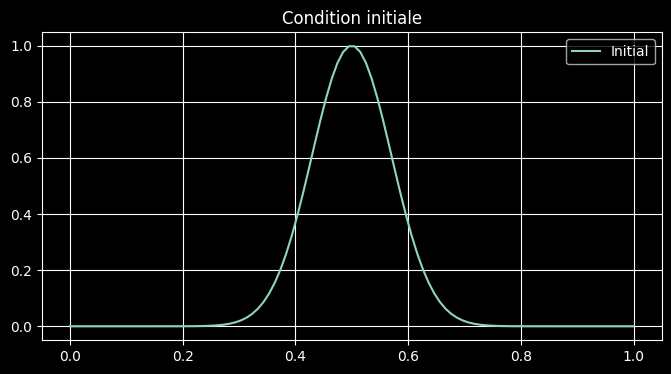

In [18]:
u0 = np.exp(-100 * (x - 0.5)**2)

plt.figure(figsize=(8, 4))
plt.plot(x, u0, label='Initial')
plt.title("Condition initiale")
plt.legend()
plt.grid(True)
plt.show()


## Résolution


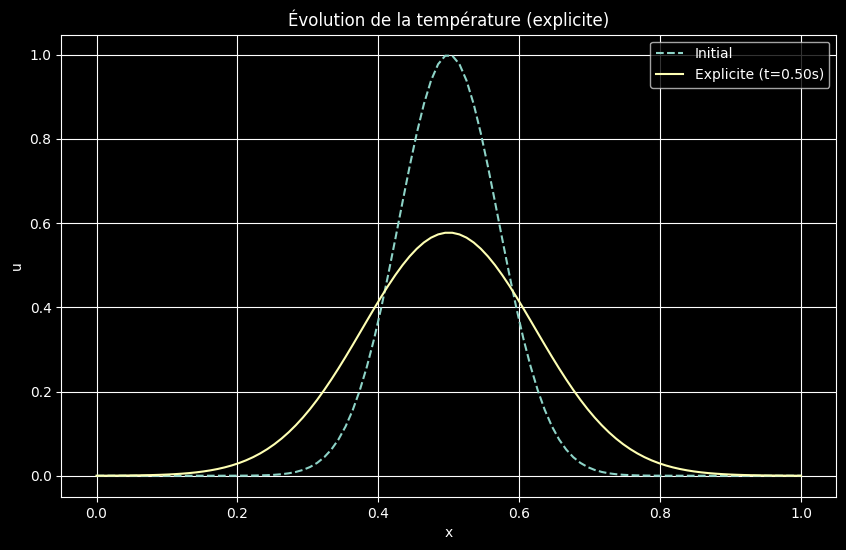

In [19]:
u_expl = solve_heat_explicit(u0.copy(), alpha, dx, dt, nt)

plt.figure(figsize=(10, 6))
plt.plot(x, u0, '--', label='Initial')
plt.plot(x, u_expl, label=f'Explicite (t={nt*dt:.2f}s)')
plt.title("Évolution de la température (explicite)")
plt.xlabel("x")
plt.ylabel("u")
plt.legend()
plt.grid(True)
plt.show()

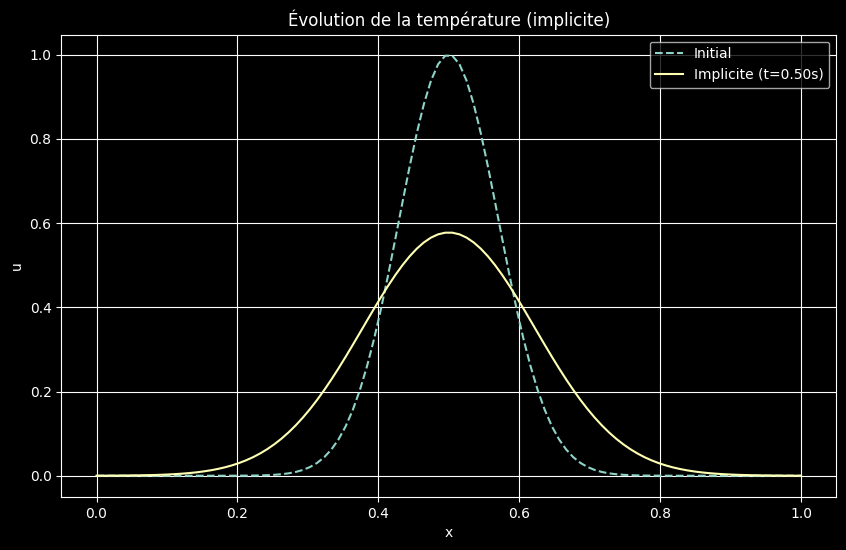

In [22]:
u_impl = solve_heat_implicit(u0.copy(), alpha, dx, dt, nt)

plt.figure(figsize=(10, 6))
plt.plot(x, u0, '--', label='Initial')
plt.plot(x, u_impl, label=f'Implicite (t={nt*dt:.2f}s)')
plt.title("Évolution de la température (implicite)")
plt.xlabel("x")
plt.ylabel("u")
plt.legend()
plt.grid(True)
plt.show()


## Comparaison des performances


In [21]:
import time

start = time.time()
solve_heat_explicit(u0.copy(), alpha, dx, dt, nt)
print(f"Temps Explicite (Numba, premier appel avec compile): {time.time() - start:.4f}s")

start = time.time()
solve_heat_explicit(u0.copy(), alpha, dx, dt, nt)
print(f"Temps Explicite (Numba, second appel): {time.time() - start:.4f}s")

start = time.time()
solve_heat_implicit(u0.copy(), alpha, dx, dt, nt)
print(f"Temps Implicite (Scipy sparse): {time.time() - start:.4f}s")


Temps Explicite (Numba, premier appel avec compile): 0.0003s
Temps Explicite (Numba, second appel): 0.0003s
Temps Implicite (Scipy sparse): 0.0368s
